# **KKBOX Churn Prediction And Retention Intelligence System - Modeling & Evaluation**
----------

## **1. Objective**

This notebook develops and evaluates the machine learning models used in the KKBOX Churn Prediction and Retention Intelligence System.

The goal is to:

- Build a high‑performance churn prediction pipeline  
- Identify the most accurate and operationally suitable model  
- Understand key behavioral and transactional drivers of churn  
- Generate explainable outputs that support retention strategy design  

The analysis here is model‑focused: preprocessing, baseline models, advanced algorithms, evaluation metrics, model comparison, and final model selection.  
The outcome is a production‑ready churn model saved as a deployable `.pkl` artifact, plus explainability views that can be surfaced in the Retention OS.

---

## **2. Setup**

In [1]:
import os
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, precision_score,
    recall_score, f1_score
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Baselines
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Advanced models
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier
)

# Explainability
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Persistence
import pickle

pd.set_option("display.max_columns", None)

-------------------------------

## **3. Load Clean Dataset**

In [2]:
current_dir = os.getcwd()

while not os.path.exists(os.path.join(current_dir, "data", "processed")):
    parent = os.path.dirname(current_dir)
    if parent == current_dir:
        raise FileNotFoundError("Project root with data/processed not found")
    current_dir = parent

os.chdir(current_dir)

df = pd.read_csv("data/processed/df_clean.csv")
df.head()

,msno,is_churn,membership_expire_date,gender,age,city_grouped,registered_via_grouped,avg_amount_paid,total_amount_paid,has_auto_renew,has_cancelled,total_secs,num_unq,customer_tenure_days,listening_group,payment_variability
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,NaN,male,28.0,5.0,3.0,0.0,0.0,0.0,0.0,80598.557,348.0,0.0,Medium-High,0.000000
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,2017-04-11,male,20.0,13.0,3.0,180.0,180.0,0.0,0.0,6986.509,30.0,1174.0,Medium-Low,90.000000
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,2017-06-15,male,18.0,13.0,3.0,150.0,300.0,0.0,0.0,67810.467,432.0,1173.0,Medium-High,100.000000
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,2018-01-08,unknown,NaN,1.0,7.0,149.0,1490.0,1.0,0.0,0.000,0.0,698.0,Low,135.454545
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,2017-09-18,female,35.0,13.0,7.0,99.0,792.0,1.0,1.0,239882.241,548.0,1146.0,High,88.000000


------------------------

## **4. Train/Test Split**

In [3]:
X = df.drop(columns=["is_churn", "msno"])
y = df["is_churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (776768, 14)
Test shape: (194192, 14)


--------------------------------------

## **5. Preprocessing Pipeline**

In [4]:
categorical_cols = ["gender", "city_grouped", "registered_via_grouped", "listening_group"]

numeric_cols = [
    "age", "avg_amount_paid", "total_amount_paid", "has_auto_renew",
    "has_cancelled", "total_secs", "num_unq", "customer_tenure_days",
    "payment_variability"
]

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    sparse_threshold=0
)

-----------------

## **6. Baseline Model Performance**

In [5]:
# 6.1 DummyClassifier 
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_recall_curve, auc

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict_proba(X_test)[:, 1]

# Compute PR-AUC
precision, recall, _ = precision_recall_curve(y_test, dummy_pred)
dummy_pr_auc = auc(recall, precision)

print("DummyClassifier PR-AUC:", dummy_pr_auc)

DummyClassifier PR-AUC: 0.5449709565790558


In [6]:
# 6.2 Logistic Regression 

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve, auc

if "preprocessor" not in globals():
    raise ValueError("'preprocessor' is not defined. Run the preprocessing cell first.")

if "X_train" not in globals() or "y_train" not in globals():
    raise ValueError("Train/test split not found. Run the split cell first.")

logreg_fast = LogisticRegression(
    solver="lbfgs",
    max_iter=500,
    n_jobs=-1
)

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", logreg_fast)
])

print("Training Logistic Regression...")
logreg_pipeline.fit(X_train, y_train)

# Predicted probabilities
logreg_pred = logreg_pipeline.predict_proba(X_test)[:, 1]

# Compute PR-AUC
precision, recall, _ = precision_recall_curve(y_test, logreg_pred)
logreg_pr_auc = auc(recall, precision)

print("Logistic Regression PR-AUC:", logreg_pr_auc)

Training Logistic Regression...
Logistic Regression PR-AUC: 0.5735167469988973


In [7]:
# 6.3 Decision Tree — PR-AUC

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, auc
from sklearn.pipeline import Pipeline

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)

# Predicted probabilities
dt_pred = dt_pipeline.predict_proba(X_test)[:, 1]

# Compute PR-AUC
precision, recall, _ = precision_recall_curve(y_test, dt_pred)
dt_pr_auc = auc(recall, precision)

print("Decision Tree PR-AUC:", dt_pr_auc)

Decision Tree PR-AUC: 0.8172317185535771


In [8]:
# 6.4 Naive Bayes — PR-AUC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_recall_curve, auc
from sklearn.pipeline import Pipeline

nb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

nb_pipeline.fit(X_train, y_train)

# Predicted probabilities
nb_pred = nb_pipeline.predict_proba(X_test)[:, 1]

# Compute PR-AUC
precision, recall, _ = precision_recall_curve(y_test, nb_pred)
nb_pr_auc = auc(recall, precision)

print("Naive Bayes PR-AUC:", nb_pr_auc)

Naive Bayes PR-AUC: 0.6490636295957628


In [9]:
# 6.5 Baseline results table — PR-AUC

pd.set_option("display.max_colwidth", None)

baseline_results = pd.DataFrame({
    "Baseline Model": [
        "DummyClassifier",
        "Logistic Regression",
        "Decision Tree (depth=3)",
        "Naive Bayes"
    ],
    "PR-AUC": [
        dummy_pr_auc,
        logreg_pr_auc,
        dt_pr_auc,
        nb_pr_auc
    ],
    "Notes": [
        "Zero-Skill; Predicts majority class only",
        "Linear and interpretable baseline",
        "Simple non-linear interactions",
        "Probabilistic; independence assumption"
    ]
}).sort_values(by="PR-AUC", ascending=False).reset_index(drop=True)

baseline_results

,Baseline Model,PR-AUC,Notes
0,Decision Tree (depth=3),0.817232,Simple non-linear interactions
1,Naive Bayes,0.649064,Probabilistic; independence assumption
2,Logistic Regression,0.573517,Linear and interpretable baseline
3,DummyClassifier,0.544971,Zero-Skill; Predicts majority class only


C:\Users\pauli\AppData\Local\Temp\ipykernel_27488\2188397545.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


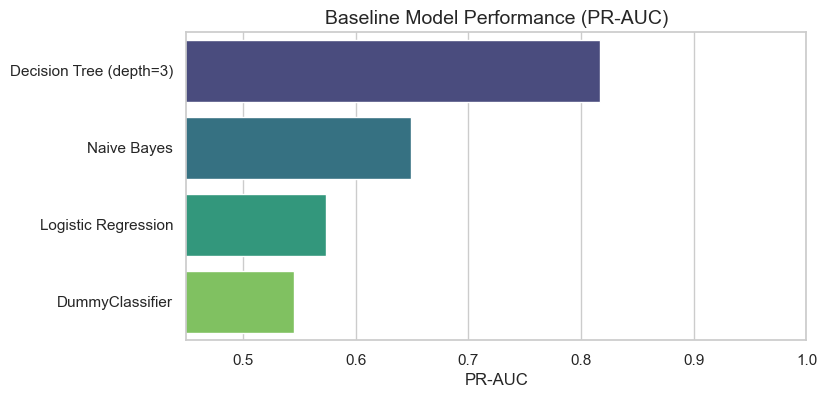

In [11]:
# 6.7 Baseline Performance Plot (PR-AUC)
sns.set(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.barplot(
    data=baseline_results,
    x="PR-AUC",
    y="Baseline Model",
    palette="viridis"
)

plt.title("Baseline Model Performance (PR-AUC)", fontsize=14)
plt.xlabel("PR-AUC")
plt.ylabel("")
plt.xlim(0.45, 1.0)
plt.show()

**Insight**

- Decision Tree: is the strongest baseline (PR-AUC 0,81).  

- Naive Bayes: performs moderately (PR-AUC 0,64).

- Logistic Regression: is stable and interpretable (PR-AUC 0,57).

- DummyClassifier:  simply mirrors the imbalance (PR-AUC 0,54). 

Together, these results show that:
>
Even simple models capture strong churn signals, with the Decision Tree already reaching high accuracy, confirming that the dataset contains clear non‑linear patterns.

In [13]:
# 6.6 Decision Tree Train/Test Score (PR-AUC)

dt_pred_train = dt_pipeline.predict_proba(X_train)[:, 1]
precision, recall, _ = precision_recall_curve(y_train, dt_pred_train)
dt_pr_auc_train = auc(recall, precision)

print("Decision Tree PR-AUC (train):", dt_pr_auc_train)
print("Decision Tree PR-AUC (test):", dt_pr_auc)

Decision Tree PR-AUC (train): 0.819718074240511
Decision Tree PR-AUC (test): 0.8172317185535771


**Insight**

- Train and test PR‑AUC scores are nearly identical (0.8197 vs 0.8172), indicating that the Decision Tree (depth=3) generalizes well and is not overfitting.

---------------------------------

## **7. Advance Model Performance**

In [12]:
# 7.1 RandomForestClassifier — PR-AUC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, rf_pred)
rf_pr_auc = auc(recall, precision)

print("RandomForest PR-AUC:", rf_pr_auc)

RandomForest PR-AUC: 0.8817755282119082


In [14]:
# 7.2 ExtraTreesClassifier — PR-AUC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import precision_recall_curve, auc

et = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

et_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", et)
])

et_pipeline.fit(X_train, y_train)

et_pred = et_pipeline.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, et_pred)
et_pr_auc = auc(recall, precision)

print("ExtraTrees PR-AUC:", et_pr_auc)

ExtraTrees PR-AUC: 0.8652414056678166


In [15]:
# 7.3 GradientBoostingClassifier — PR-AUC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_recall_curve, auc

gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    random_state=42
)

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", gb_model)
])

gb_pipeline.fit(X_train, y_train)

gb_pred = gb_pipeline.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, gb_pred)
gb_pr_auc = auc(recall, precision)

print("GradientBoosting PR-AUC:", gb_pr_auc)

GradientBoosting PR-AUC: 0.8875538090422259


In [16]:
# 7.4 HistGradientBoostingClassifier — PR-AUC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_recall_curve, auc

hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    random_state=42
)

hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", hgb_model)
])

hgb_pipeline.fit(X_train, y_train)

hgb_pred = hgb_pipeline.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, hgb_pred)
hgb_pr_auc = auc(recall, precision)

print("HistGradientBoosting PR-AUC:", hgb_pr_auc)

c:\Users\pauli\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Das System kann die angegebene Datei nicht finden
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\pauli\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\pauli\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pauli\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^

HistGradientBoosting PR-AUC: 0.9003456969068794


In [17]:
# 7.5 Advanced Model Results Table — PR-AUC
pr_results = pd.DataFrame({
    "Model": [
        "HistGradientBoosting",
        "Gradient Boosting",
        "Random Forest",
        "Extra Trees",
        "Decision Tree (depth=3)",
        "Naive Bayes",
        "Logistic Regression",
        "DummyClassifier"
    ],
    "PR-AUC": [
        hgb_pr_auc,
        gb_pr_auc,
        rf_pr_auc,
        et_pr_auc,
        dt_pr_auc,
        nb_pr_auc,
        logreg_pr_auc,
        dummy_pr_auc
    ],
    "Notes": [
        "Best at detecting early churn signals; captures complex customer behavior patterns.",
        "Strong at identifying behaviors that typically precede churn; consistent and reliable.",
        "Finds meaningful combinations of customer actions that indicate churn risk.",
        "Captures useful patterns but with slightly less precision than the top models.",
        "Provides simple, easy-to-explain rules about what differentiates customers who stay vs. leave.",
        "Gives a quick churn risk estimate but misses important behavior interactions.",
        "Simple and interpretable, but overlooks complex churn drivers present in the data.",
        "Assumes all customers stay; serves only as a minimum benchmark for comparison."
    ]
})

pr_results = pr_results.sort_values(by="PR-AUC", ascending=False).reset_index(drop=True)
pr_results

,Model,PR-AUC,Notes
0,HistGradientBoosting,0.900346,Best at detecting early churn signals; captures complex customer behavior patterns.
1,Gradient Boosting,0.887554,Strong at identifying behaviors that typically precede churn; consistent and reliable.
2,Random Forest,0.881776,Finds meaningful combinations of customer actions that indicate churn risk.
3,Extra Trees,0.865241,Captures useful patterns but with slightly less precision than the top models.
4,Decision Tree (depth=3),0.817232,"Provides simple, easy-to-explain rules about what differentiates customers who stay vs. leave."
5,Naive Bayes,0.649064,Gives a quick churn risk estimate but misses important behavior interactions.
6,Logistic Regression,0.573517,"Simple and interpretable, but overlooks complex churn drivers present in the data."
7,DummyClassifier,0.544971,Assumes all customers stay; serves only as a minimum benchmark for comparison.


**Insight**

- Best models: HistGradientBoosting (0.90), Gradient Boosting (0.88) and Random Forest (0.88). This models understand customer behavior well and can spot who is likely to leave early.

- Extra Trees (0.86) is still good, but miss important behavior patterns, so they identify fewer at‑risk customers

- Naive Bayes (0.64) and Logistic Regression (0.57) don’t capture the real patterns.  
Churn in our business is not simple, so these models can’t explain it well.

- The Dummy model (0.545) just reflects that most customers stay.  
All real models perform much better, showing that our advanced models truly add value.

-------

## **8. Model Evaluation & Comparison**

In [18]:
# 8.1 Compute Full Metrics for Imbalanced Classification
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    accuracy_score, confusion_matrix, balanced_accuracy_score
)

def compute_metrics(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp)

    return {
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4),
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Specificity": round(specificity, 4),
        "Balanced Accuracy": round(balanced_accuracy_score(y_true, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_pred_proba), 6),
        "PR-AUC": round(average_precision_score(y_true, y_pred_proba), 6)
    }

rf_metrics  = compute_metrics(y_test, rf_pred)
et_metrics  = compute_metrics(y_test, et_pred)
gb_metrics  = compute_metrics(y_test, gb_pred)
hgb_metrics = compute_metrics(y_test, hgb_pred)

In [19]:
# 8.2 Final Model Comparison Table

advanced_results = pd.DataFrame([
    {
        "Model": "HistGradientBoosting",
        **hgb_metrics,
        "Notes": "Fastest boosting model, LightGBM-like"
    },
    {
        "Model": "GradientBoosting",
        **gb_metrics,
        "Notes": "Classic boosting, high accuracy"
    },
    {
        "Model": "RandomForest",
        **rf_metrics,
        "Notes": "Robust, strong non-linear baseline"
    },
    {
        "Model": "ExtraTrees",
        **et_metrics,
        "Notes": "Fast, stable, strong performance"
    }
])

advanced_results = advanced_results.sort_values(
    by="ROC-AUC", ascending=False
).reset_index(drop=True)

advanced_results

,Model,Precision,Recall,F1,Accuracy,Specificity,Balanced Accuracy,ROC-AUC,PR-AUC,Notes
0,HistGradientBoosting,0.8561,0.8277,0.8417,0.9720,0.9862,0.9070,0.980080,0.900296,"Fastest boosting model, LightGBM-like"
1,GradientBoosting,0.8470,0.8192,0.8329,0.9704,0.9854,0.9023,0.975819,0.887292,"Classic boosting, high accuracy"
2,RandomForest,0.8619,0.7909,0.8249,0.9698,0.9875,0.8892,0.970308,0.879809,"Robust, strong non-linear baseline"
3,ExtraTrees,0.8445,0.7785,0.8102,0.9672,0.9858,0.8822,0.965721,0.861614,"Fast, stable, strong performance"


**Insight**

- The top two models (HGB + GB) are consistently strong across most of the metric

- Random Forest and Extra Trees are good, but not good enough to catch churn early and accurately

- The gap in Recall and PR‑AUC shows that boosting models identify more real churners, which directly improves retention impact

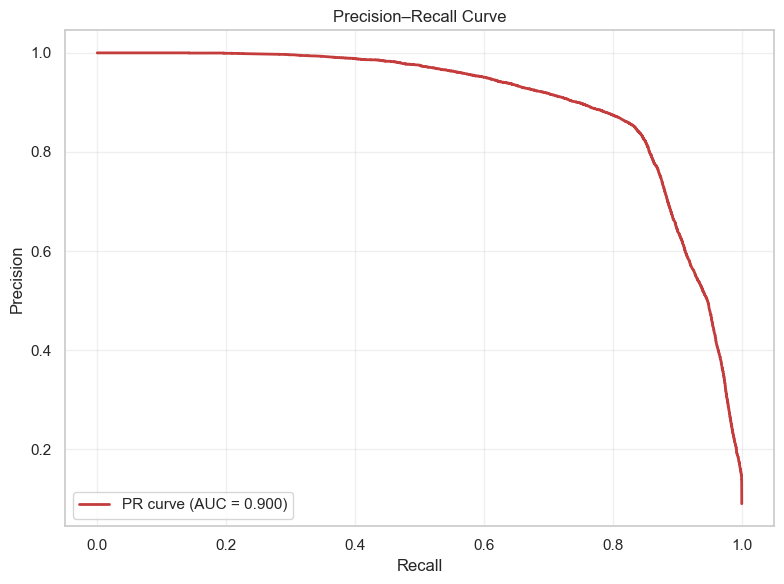

In [20]:
# 8.3 PR-AUC Curve for Best Model

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_proba = hgb_pred  

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))

plt.plot(recall, precision, color="#C43C3C", lw=2,
         label=f"PR curve (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**

- The Hgb model keeps precision high across a wide recall range, showing it can detect churners without generating many false positives.

- A PR‑AUC of 0.90 reflects excellent performance in an imbalanced churn setting, meaning the model reliably separates churners from non‑churners.

- The curve declines smoothly, indicating stable predictions where precision decreases gradually as recall increases.

- Overall, the curve confirms strong ability to identify true churners, making it well‑suited for targeted retention strategies where catching the right customers matters.

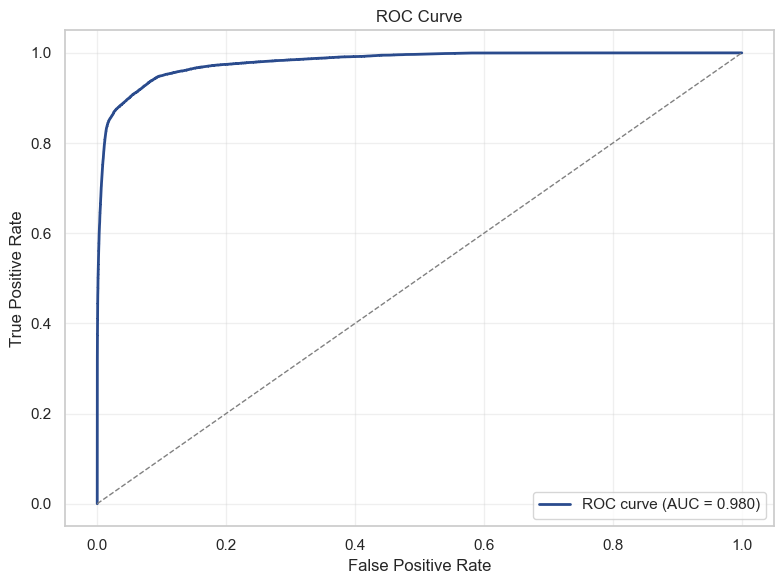

In [21]:
# 8.4 ROC Curve for Best Model

from sklearn.metrics import roc_curve, auc

y_proba = hgb_pred  

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color="#2A4B8D", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**

- AUC of 0.98 shows exceptional discriminative power, confirming taht the model reliably ranks churners above non‑churners.

- The curve stays close to the top‑left corner, indicating strong sensitivity with minimal false alarms.

- Performance is consistent across thresholds, making the model stable for operational decision‑making.

- This level of separation enables confident prioritization of high‑risk customers in retention workflows.

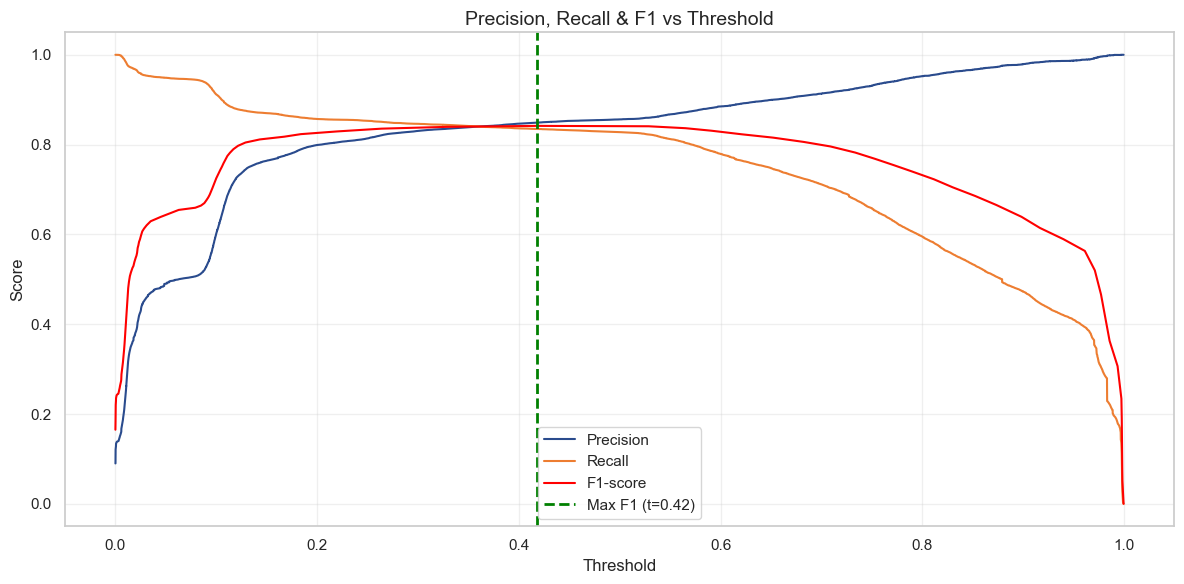

Best threshold for F1: 0.4176
Max F1-score: 0.8417


In [22]:
# 8.5 Precision-Recall Curve & F1 vs Threshold

from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

y_proba = hgb_pred  

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

idx = np.linspace(0, len(thresholds)-1, 200).astype(int)
thresholds_reduced = thresholds[idx]

f1_scores = []
for t in thresholds_reduced:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

f1_scores = np.array(f1_scores)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds_reduced[best_idx]
best_f1 = f1_scores[best_idx]

plt.figure(figsize=(12, 6))

plt.plot(thresholds, precision[:-1], label="Precision", color="#2A4B8D")
plt.plot(thresholds, recall[:-1], label="Recall", color="#ED7D31")

plt.plot(thresholds_reduced, f1_scores, label="F1-score", color="red")

plt.axvline(best_threshold, color="green", linestyle="--", linewidth=2,
            label=f"Max F1 (t={best_threshold:.2f})")

plt.title("Precision, Recall & F1 vs Threshold", fontsize=14)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold for F1: {best_threshold:.4f}")
print(f"Max F1-score: {best_f1:.4f}")

**Insight**

This plot shows how the model behaves as we adjust the decision threshold:

- At low thresholds, recall is high because the model flags almost every potential churner, but precision drops since many of those alerts are false alarms.

- As the threshold increases, precision improves (fewer false positives), but recall decreases because the model starts missing real churners.

- The best balance appears around a threshold of ~0.42, where the F1‑score peaks.
This point represents the sweet spot: we catch a large share of true churners while keeping unnecessary retention actions under control.

- It’s worth noting that between thresholds 0.3 and 0.5, both precision and recall stay high (around 0.8). This means the model is consistently confident in this range and rarely outputs uncertain probabilities around 0.4-0.5, a sign of stable, reliable predictions.

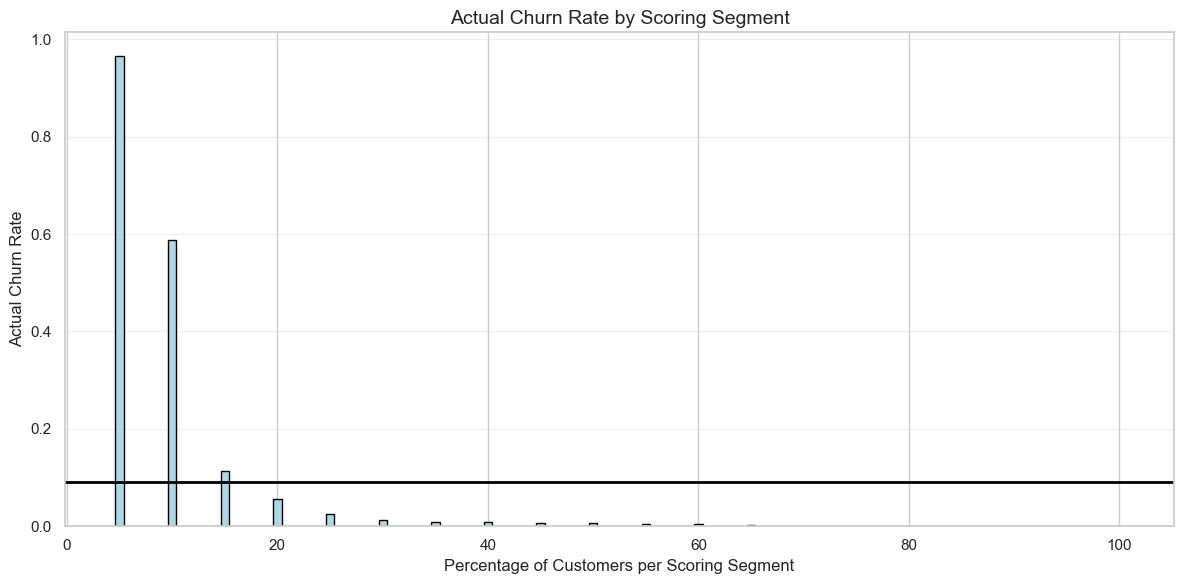

In [24]:
# 8.6 Gain Chart (Lift Chart)

y_proba = hgb_pipeline.predict_proba(X_test)[:, 1]

df_gain = pd.DataFrame({
    "proba": y_proba,
    "churn": y_test.values
})

df_gain = df_gain.sort_values("proba", ascending=False).reset_index(drop=True)

# Create percentile bins (20 bins = 5% each)
df_gain["percentile"] = pd.qcut(df_gain.index, 20, labels=False)

gain_table = df_gain.groupby("percentile").agg(
    churn_rate=("churn", "mean"),
    count=("churn", "size")
).reset_index()

gain_table["percentile"] = (gain_table["percentile"] + 1) * 5  

plt.figure(figsize=(12, 6))

plt.bar(
    gain_table["percentile"],
    gain_table["churn_rate"],
    color="#ADD8E6",  
    edgecolor="black"
)

plt.axhline(df_gain["churn"].mean(), color="black", linewidth=2)

plt.title("Actual Churn Rate by Scoring Segment", fontsize=14)
plt.xlabel("Percentage of Customers per Scoring Segment")
plt.ylabel("Actual Churn Rate")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Insight**

Lift shows how much better the model is at finding churners compared to selecting customers at random. The plot shows that:

- The top scoring segments contain far more churners than the average churn rate, meaning the model concentrates risk extremely well.

- The first 5–10% of customers ranked by the model show the highest churn rates, proving that the model identifies a small group where churn is heavily concentrated.

- This allows the business to focus retention efforts on a small portion of customers while capturing a large share of churners, reducing cost and increasing ROI.

- A high‑lift model means retention teams don’t need to contact everyone — only the top‑ranked segments — to achieve strong impact.

Practically, lift answers the question: “If we only have budget to contact 10–20% of customers, how many churners can we realistically catch?

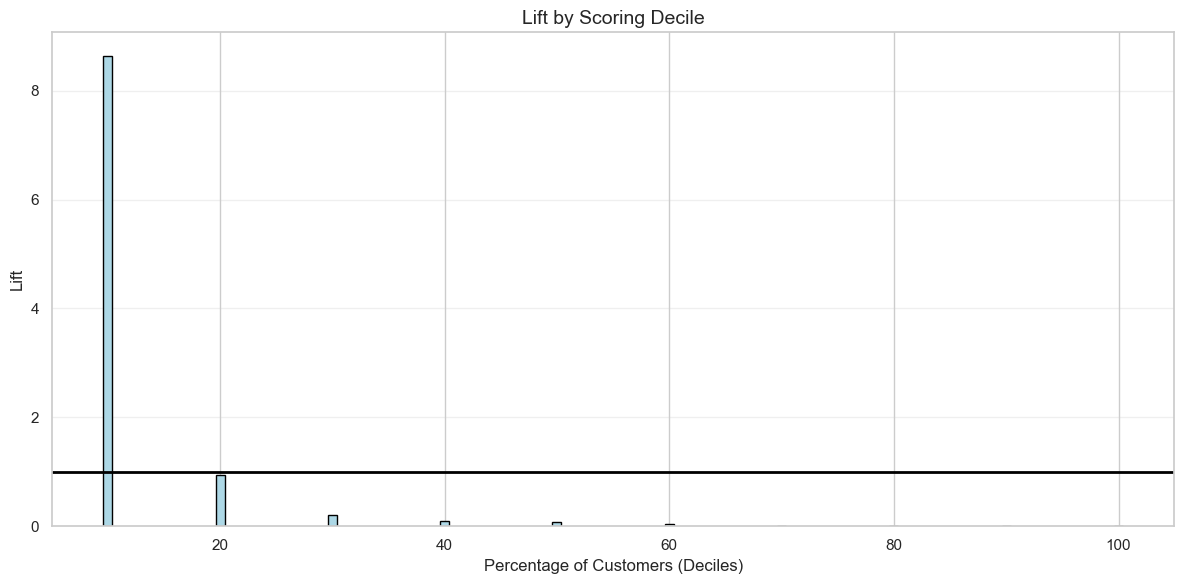

In [25]:
# 8.7 Lift Chart by Deciles
y_proba = hgb_pipeline.predict_proba(X_test)[:, 1]

df_lift = pd.DataFrame({
    "proba": y_proba,
    "churn": y_test.values
})

df_lift = df_lift.sort_values("proba", ascending=False).reset_index(drop=True)

df_lift["decile"] = pd.qcut(df_lift.index, 10, labels=False)

lift_table = df_lift.groupby("decile").agg(
    churn_rate=("churn", "mean")
).reset_index()

baseline = df_lift["churn"].mean()

lift_table["lift"] = lift_table["churn_rate"] / baseline
lift_table["decile"] = (lift_table["decile"] + 1) * 10  # 10%, 20%, ...

plt.figure(figsize=(12, 6))

plt.bar(
    lift_table["decile"],
    lift_table["lift"],
    color="#ADD8E6",
    edgecolor="black"
)

plt.axhline(1.0, color="black", linewidth=2)

plt.title("Lift by Scoring Decile", fontsize=14)
plt.xlabel("Percentage of Customers (Deciles)")
plt.ylabel("Lift")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**insight**

- The top decile is 8–9× more effective than random selection, proving the model isolates high‑value churners with exceptional precision.

- Lift collapses after the first decile. As expected, the model is concentrating value early.

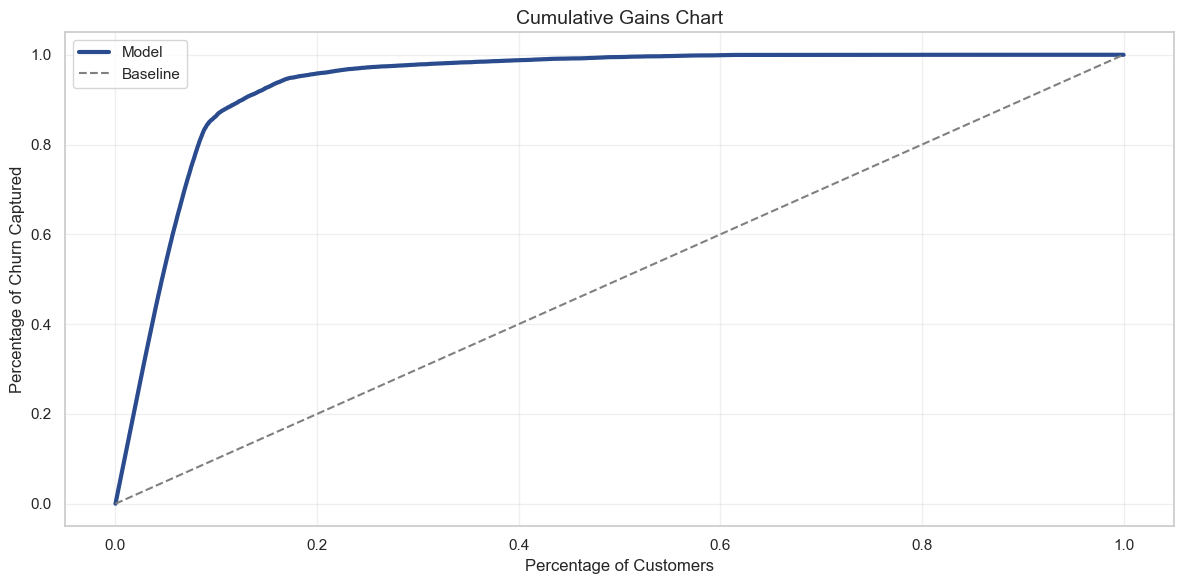

In [26]:
# 8.8 Cumulative Gains Chart

df_gain2 = df_lift.copy()

df_gain2["cum_churn"] = df_gain2["churn"].cumsum()
df_gain2["cum_pct_churn"] = df_gain2["cum_churn"] / df_gain2["churn"].sum()

df_gain2["cum_customers"] = np.arange(1, len(df_gain2) + 1)
df_gain2["cum_pct_customers"] = df_gain2["cum_customers"] / len(df_gain2)

plt.figure(figsize=(12, 6))

plt.plot(
    df_gain2["cum_pct_customers"],
    df_gain2["cum_pct_churn"],
    color="#2A4B8D",
    linewidth=3,
    label="Model"
)

# Baseline (random model)
plt.plot(
    df_gain2["cum_pct_customers"],
    df_gain2["cum_pct_customers"],
    color="gray",
    linestyle="--",
    label="Baseline"
)

plt.title("Cumulative Gains Chart", fontsize=14)
plt.xlabel("Percentage of Customers")
plt.ylabel("Percentage of Churn Captured")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Insight**

The cumulative gains chart confirms the same pattern observed in the lift analysis: 

- The model captures churners much faster than random selection.

- The top customer segments contain a disproportionately high share of churn, validating that the model ranks customers effectively by churn risk.

- Compared to the baseline, the model reaches high churn capture rates with far fewer customers contacted, reinforcing its value for targeted retention.

----

## **9. Model Selection**

C:\Users\pauli\AppData\Local\Temp\ipykernel_27488\2013255947.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


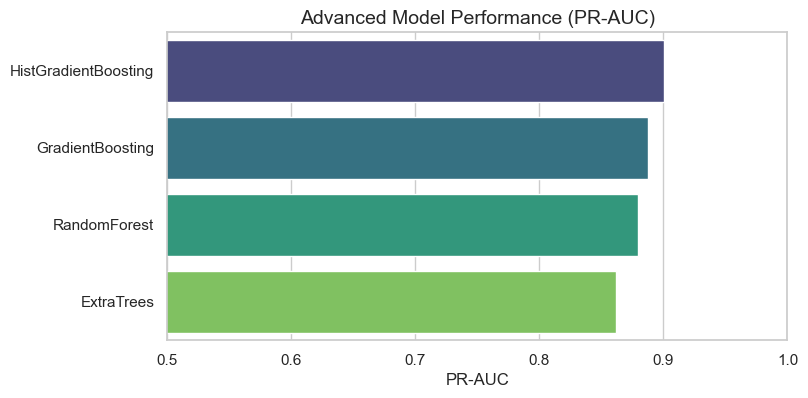

Best model based on PR-AUC: HistGradientBoosting
PR-AUC Score: 0.900346

Reasoning:
- PR-AUC is the most informative metric for churn prediction because it focuses on the minority class (churners).
- It evaluates how well the model identifies true churners while minimizing false positives.
- PR-AUC is more sensitive than ROC-AUC in imbalanced datasets and reflects real business performance.
- HistGradientBoosting achieved the highest PR-AUC, making it the strongest model for detecting churn risk.


In [30]:
# Best Model Selection (based on PR‑AUC for imbalanced churn prediction)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=advanced_results,
    x="PR-AUC",
    y="Model",
    palette="viridis"
)

plt.title("Advanced Model Performance (PR-AUC)", fontsize=14)
plt.xlabel("PR-AUC")
plt.ylabel("")
plt.xlim(0.50, 1.0)
plt.show()

pr_results = pd.DataFrame([
    {"Model": "HistGradientBoosting", "PR-AUC": round(hgb_pr_auc, 6)},
    {"Model": "GradientBoosting", "PR-AUC": round(gb_pr_auc, 6)},
    {"Model": "RandomForest", "PR-AUC": round(rf_pr_auc, 6)},
    {"Model": "ExtraTrees", "PR-AUC": round(et_pr_auc, 6)}
])

pr_results = pr_results.sort_values(by="PR-AUC", ascending=False).reset_index(drop=True)
pr_results

best_model = pr_results.iloc[0]

print(f"Best model based on PR-AUC: {best_model['Model']}")
print(f"PR-AUC Score: {best_model['PR-AUC']}")

print("\nReasoning:")
print("- PR-AUC is the most informative metric for churn prediction because it focuses on the minority class (churners).")
print("- It evaluates how well the model identifies true churners while minimizing false positives.")
print("- PR-AUC is more sensitive than ROC-AUC in imbalanced datasets and reflects real business performance.")
print(f"- {best_model['Model']} achieved the highest PR-AUC, making it the strongest model for detecting churn risk.")

-----

## **10. Advanced Explainability & Model Intelligence**

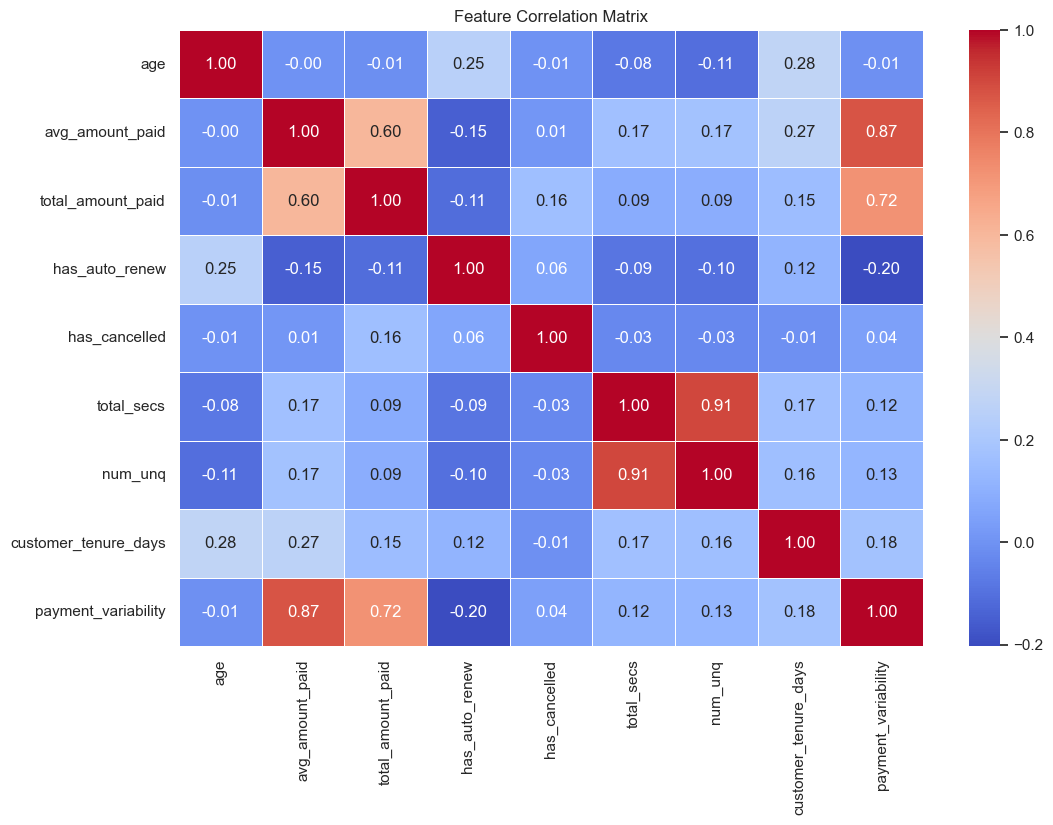

In [31]:
# 10.1 Feature Importance Analysis for the Best Model (HistGradientBoosting)
plt.figure(figsize=(12, 8))

corr = df[numeric_cols].corr() 
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

**Insight**

The heatmap confirms low multicollinearity across most features, except for expected clusters in engagement (0.91) and payments (0.87). This structure ensures the model can distinguish between financial signals and behavioral intent without redundancy issues.

In [69]:
# 10.2 Permutation Importance for the Best Model (HistGradientBoosting)

hgb_pipeline.fit(X_train, y_train)

X_test_transformed = hgb_pipeline.named_steps["preprocessor"].transform(X_test)

model_only = hgb_pipeline.named_steps["model"]

ohe = hgb_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
num_feature_names = numeric_cols
feature_names = np.concatenate([num_feature_names, cat_feature_names])

perm_result = permutation_importance(
    model_only,
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = (
    pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

pd.set_option("display.float_format", "{:.6f}".format)

importances.head(33)

,feature,importance_mean,importance_std
0,total_amount_paid,0.073011,0.000362
1,avg_amount_paid,0.042992,0.000261
2,has_cancelled,0.035437,0.000158
3,has_auto_renew,0.028181,0.000286
4,num_unq,0.007216,0.000114
5,customer_tenure_days,0.005564,0.000130
6,payment_variability,0.003267,0.000095
7,registered_via_grouped_7.0,0.001500,0.000088
8,total_secs,0.001050,0.000097
9,city_grouped_1.0,0.000168,0.000052


**Insight**

- The top four features dominate the model, all related to payment intensity and subscription stability.

- Cancellation and auto‑renewal appear as strong churn signals, reflecting explicit subscription lifecycle decisions.

- Engagement features appear below payment features in importance, indicating they contribute but are not primary drivers in the model.
The correlation matrix confirms this: engagement variables (e.g., total_secs, num_unq) are strongly correlated with each other (up to 0.91) but only moderately correlated with payment variables. This suggests that part of their predictive signal overlaps with payment behavior, which explains why payment features dominate permutation importance.  

- Demographic variables show low direct importance, though they may still influence churn indirectly.
The correlation matrix shows that demographic variables (e.g., age) have weak linear relationships with all other features, which is consistent with their low direct importance. However, their indirect influence may emerge through interactions with behavioral variables (e.g., tenure or engagement), which requires SHAP interaction analysis to fully confirm.  

C:\Users\pauli\AppData\Local\Temp\ipykernel_27488\30588415.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


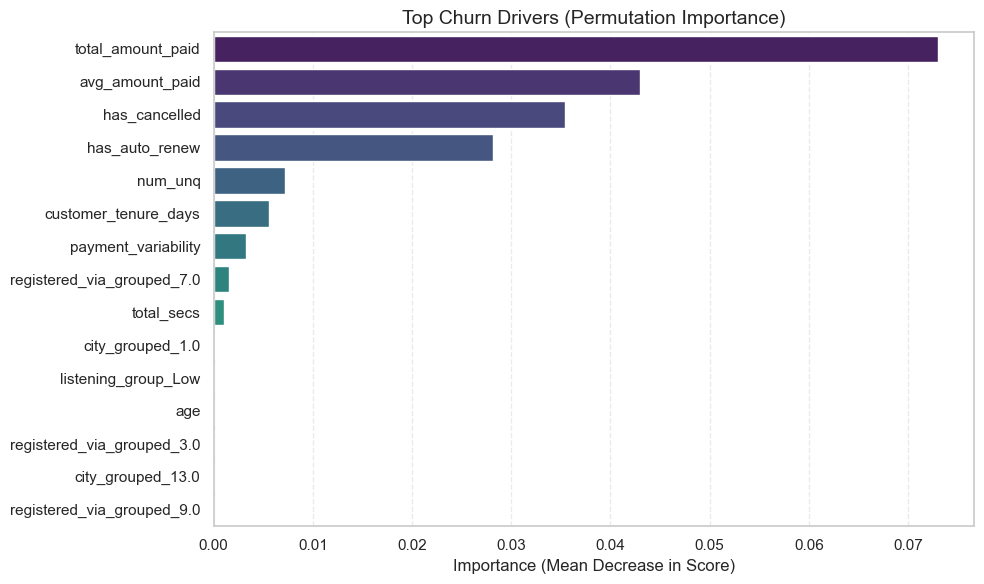

In [33]:
# 10.3. Sort importances
top_imp = importances.sort_values("importance_mean", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_imp,
    x="importance_mean",
    y="feature",
    palette="viridis"
)

plt.title("Top Churn Drivers (Permutation Importance)", fontsize=14)
plt.xlabel("Importance (Mean Decrease in Score)")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [35]:
# 10.4 Gauge Chart (Executive Churn Meter)
from matplotlib.patches import Circle, Wedge, Rectangle

def degree_range(n): 
    start = np.linspace(0,180,n+1, endpoint=True)[0:-1]
    end = np.linspace(0,180,n+1, endpoint=True)[1::]
    mid_points = start + ((end-start)/2.)
    return np.c_[start, end], mid_points

def rot_text(ang): 
    rotation = np.degrees(np.radians(ang) * np.pi / np.pi - np.radians(90))
    return rotation

def gauge(labels=['LOW','MEDIUM','HIGH','EXTREME'],
          colors=['#007A00','#0063BF','#FFCC00','#ED1C24'],
          probability=0.5,
          title="Churn Probability Gauge",
          fname=None):

    N = len(labels)
    colors = colors[::-1]
    labels = labels[::-1]

    fig, ax = plt.subplots(figsize=(6, 4))

    ang_range, mid_points = degree_range(N)

    patches = []
    for ang, c in zip(ang_range, colors):
        patches.append(Wedge((0.,0.), .4, *ang, facecolor='w', lw=2))
        patches.append(Wedge((0.,0.), .4, *ang, width=0.10, facecolor=c, lw=2, alpha=0.5))

    for p in patches:
        ax.add_patch(p)

    for mid, lab in zip(mid_points, labels):
        ax.text(0.35 * np.cos(np.radians(mid)),
                0.35 * np.sin(np.radians(mid)),
                lab,
                ha='center', va='center',
                fontsize=12, fontweight='bold',
                rotation=rot_text(mid))

    r = Rectangle((-0.4,-0.1),0.8,0.1, facecolor='w', lw=2)
    ax.add_patch(r)

    ax.text(0, -0.05,
            f"{title}: {probability:.2%}",
            ha='center', va='center',
            fontsize=14, fontweight='bold')

    pos = (1 - probability) * 180
    ax.arrow(0, 0,
             0.225 * np.cos(np.radians(pos)),
             0.225 * np.sin(np.radians(pos)),
             width=0.03, head_width=0.06, head_length=0.08,
             fc='black', ec='black')

    ax.add_patch(Circle((0, 0), radius=0.02, facecolor='black'))
    ax.add_patch(Circle((0, 0), radius=0.01, facecolor='white', zorder=11))

    ax.set_frame_on(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('equal')

    plt.tight_layout()

    if fname:
        fig.savefig(fname, dpi=200)

    plt.show()


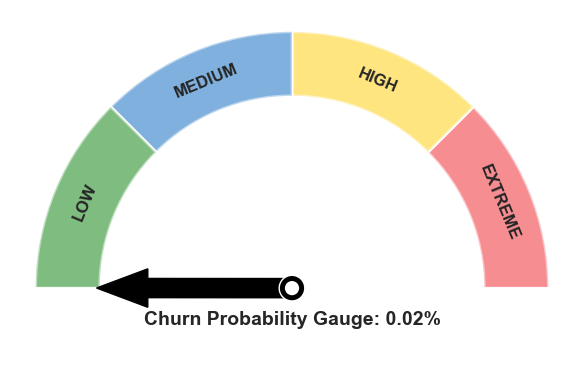

In [36]:
# 10.5 Example usage of the gauge with the predicted probability for the first test instance

prob_example = hgb_pipeline.predict_proba(X_test.iloc[0:1])[0,1]
gauge(probability=prob_example)

**Insight**

- The churn gauge provides an intuitive, executive‑friendly view of individual customer risk, enabling rapid triage for retention actions

- This visualization bridges model output and operational decision‑making by translating probabilities into clear risk categories

-----

## **11. Partial Dependence For Top Features (Behavioral Analysis)**

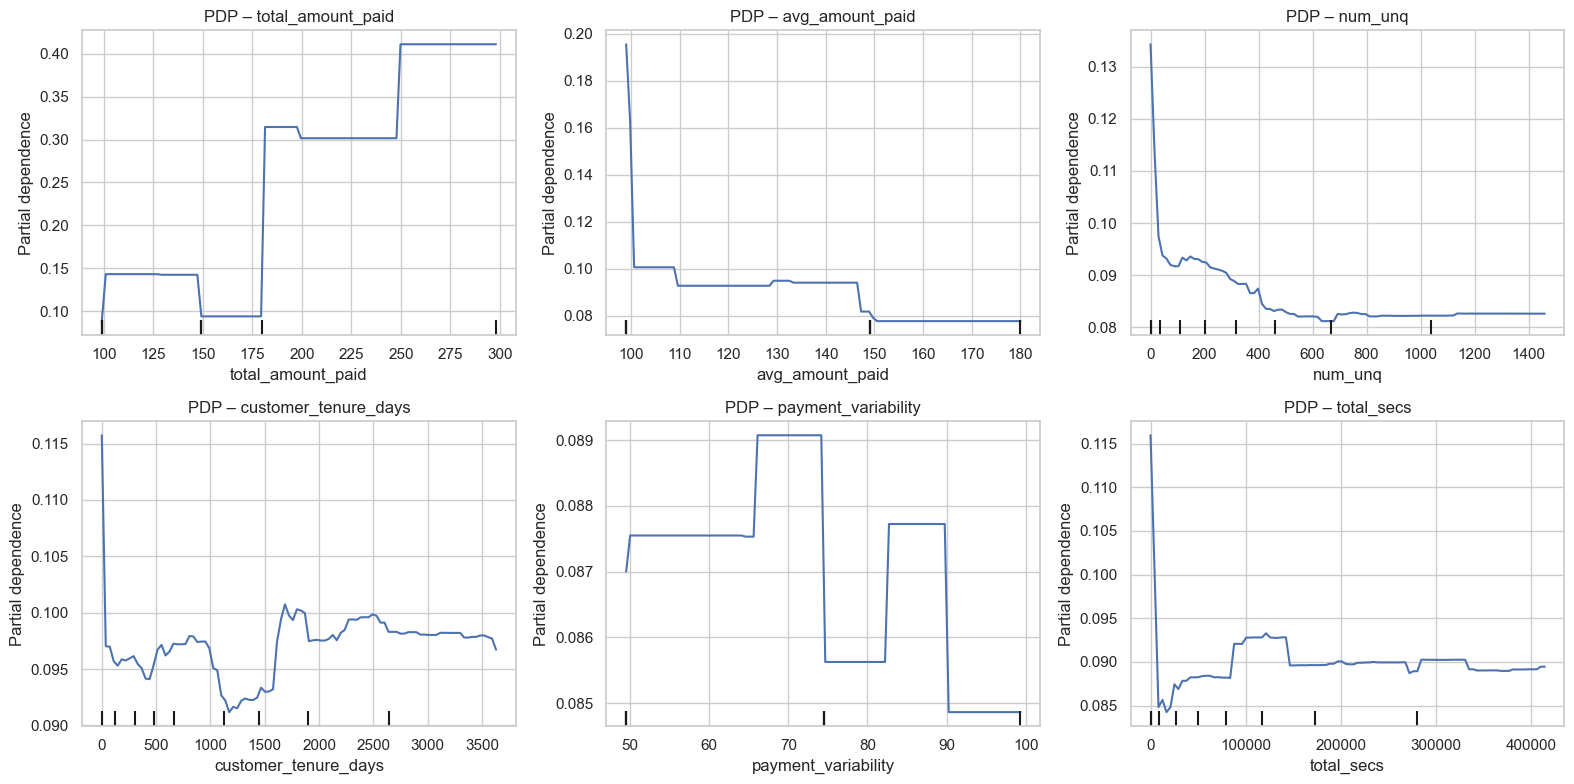

In [60]:
# Partial Dependence Plots (PDP) help us understand how the model’s predicted churn
# probability changes as we vary one feature at a time, holding all others constant.
# We generate PDPs only for the top numeric features identified by permutation importance.
# This allows us to interpret the model’s behavior in a business‑relevant way and explain
# how key customer behaviors (payments, engagement, tenure) influence churn risk.

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

pdp_features = [
    "total_amount_paid",
    "avg_amount_paid",
    "num_unq",
    "customer_tenure_days",
    "payment_variability",
    "total_secs"
]

fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax = ax.ravel()

for i, feat in enumerate(pdp_features):
    PartialDependenceDisplay.from_estimator(
        hgb_pipeline,
        X_test,
        [feat],
        ax=ax[i]
    )
    ax[i].set_title(f"PDP – {feat}")

plt.tight_layout()
plt.show()

**Insight**

- PDP for total_amount_paid:

     - Higher total_amount_paid reduces churn in clear steps.

     - Strong drop around the 100–200 range.

     - High cumulative spenders show stronger commitment and lower churn risk.

→ Prioritize high‑value customers with proactive loyalty perks (small benefits e.g., early access to new features, bonus credits, exclusive playlists, anniversary rewards, priority support).

- PDP for avg_amount_paid: 

     - Higher avg_amount_paid steadily lowers churn.

     - Curve flattens at mid‑range values.

     - Customers paying higher average amounts are more stable.

→ Protect medium‑to‑high average spenders with tailored value‑reinforcement campaigns to maintain their stable payment behavior.

- PDP for num_unq:

     - More unique content consumed sharply reduces churn early on.

     - Decline slows after ~200–300 items.

     - Broad early content exploration signals lower churn risk.

→ Boost early‑stage content exploration with personalized discovery playlists to reduce churn in the first usage window.

- PDP for customer_tenure_days:

     - Churn drops quickly as tenure increases.

     - Stabilization around 1000–1500 days.

     - Long‑tenure customers are significantly more loyal.

→ Strengthen onboarding and early‑tenure engagement flows, since the first months are the highest‑risk period.

- PDP for payment_variability:

     - Higher variability generally increases churn.

     - Sharp fluctuations around 70–90.

     - Irregular payment behavior is a strong churn signal.

→ Target customers with irregular payment patterns using billing reminders, payment‑method optimization, and friction‑reduction nudges.

- PDP for total_secs:

     - More listening time reduces churn early on.

     - Effect levels off after initial usage.

     - Higher engagement correlates with slightly lower churn risk.

→ Increase listening time through habit‑building nudges (daily mixes, streaks, recommendations) to stabilize engagement early

---

## **12. SHAP Dependence Plots (Interaction Analysis)**

In [41]:
# 12.1 SHAP Dependence Plots 
import shap

shap.initjs()

# Extract model and transformed data
model_only = hgb_pipeline.named_steps["model"]
X_test_transformed = hgb_pipeline.named_steps["preprocessor"].transform(X_test)

# Build SHAP explainer
explainer = shap.TreeExplainer(model_only)
shap_values = explainer.shap_values(X_test_transformed)

# Correct extraction of feature names
ohe = hgb_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
num_feature_names = numeric_cols
feature_names = np.concatenate([num_feature_names, cat_feature_names])

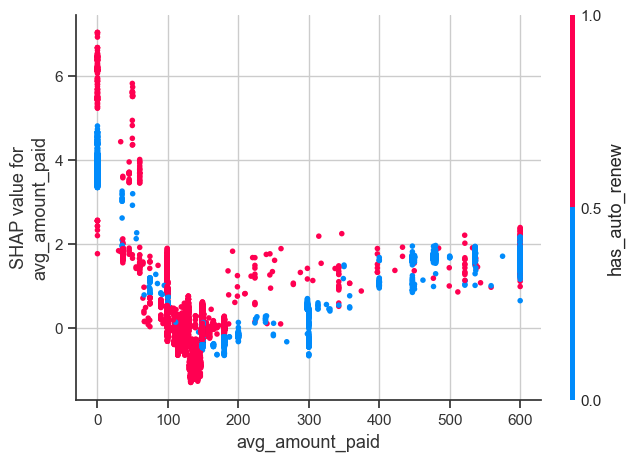

In [42]:
# 12.2 SHAP Dependence avg_amount_paid by has_auto_renew

# We analyze if the effect of avg_amount_paid on churn changes depending 
# on whether the user has auto-renew enabled. This interaction tests 
# if high-paying users with auto-renew represent the most retention-secure segment.

shap.dependence_plot(
    feature_names.tolist().index("avg_amount_paid"),
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index=feature_names.tolist().index("has_auto_renew")
)

**Insight**

- Red points (auto‑renew = 1) sit lower on the SHAP axis as avg_amount_paid increases → paying more + auto‑renew strongly reduces churn risk.

- Blue points (auto‑renew = 0) stay higher, especially at low avg_amount_paid → low spend + no auto‑renew = highest churn risk.

- Clear vertical separation: red consistently below blue → auto‑renew amplifies the stabilizing effect of higher payments, except for a small number of red points at very low payment amount, confirming very low payment amount increases churn even with autorenew enabled.

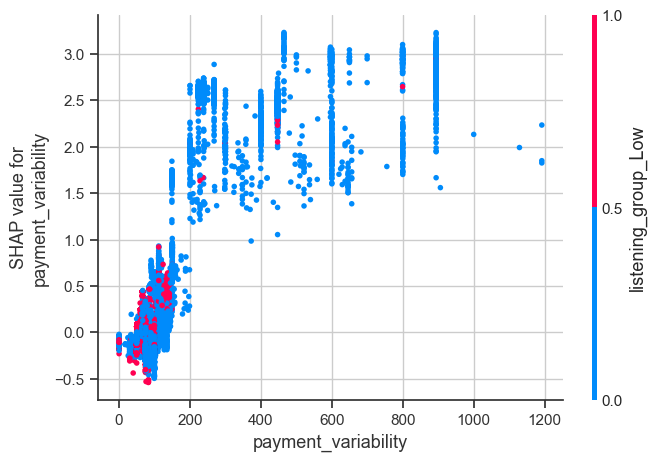

In [43]:
# 12.3 SHAP Dependence payment_variability by listening_group

# We test whether the churn impact of payment_variability depends 
# on the user's listening_group. This interaction helps identify whether 
# low-engagement users with unstable payments represent a high-risk churn cluster.

shap.dependence_plot(
    feature_names.tolist().index("payment_variability"),
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index=feature_names.tolist().index("listening_group_Low")
)

**Insight**

- Low‑engagement users (listening_group = Low) cluster toward the upper range of SHAP values when payment variability is high.

- This indicates that unstable payments are especially risky when combined with low engagement, forming a clear high‑risk churn profile.

- For other listening groups, the SHAP pattern is similar but less pronounced, suggesting that payment instability is a universal churn driver, but its impact is amplified when engagement is weak.

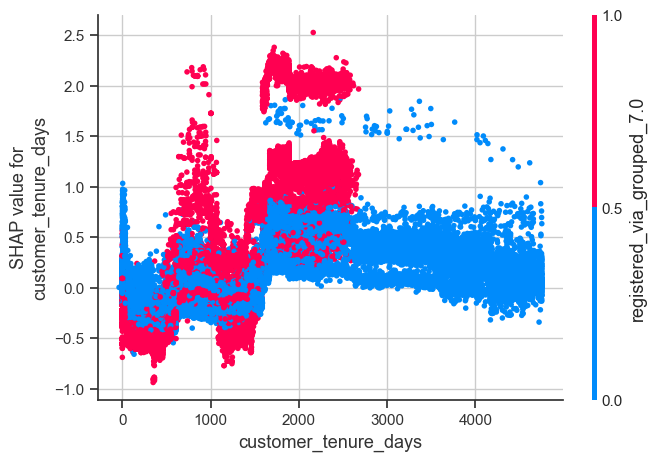

In [44]:
# 12.4 SHAP Dependence customer_tenure_days by registered_via_grouped_7.0

# We explore whether the effect of customer_tenure_days 
# on churn varies for users registered via channel 7. 
# This interaction helps detect channel-specific onboarding weaknesses 
# that elevate early churn.

shap.dependence_plot(
    feature_names.tolist().index("customer_tenure_days"),
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index=feature_names.tolist().index("registered_via_grouped_7.0")
)

**Insight**

Tenure has the same overall pattern for both colors (blue = not channel 7, red = channel 7):

- As tenure increases, SHAP values drop, meaning longer‑tenure users are less likely to churn regardless of channel.

- Red points (channel 7) do not show a distinct upward or downward shift compared to blue points.
This means channel 7 users do not experience a different churn‑tenure relationship.

- Early‑tenure users (left side of the plot) show higher SHAP values for both colors →
early‑life churn risk is high across all channels, not specifically worse for channel 7.

No visible separation between red and blue suggests no channel‑specific onboarding weakness tied to tenure.

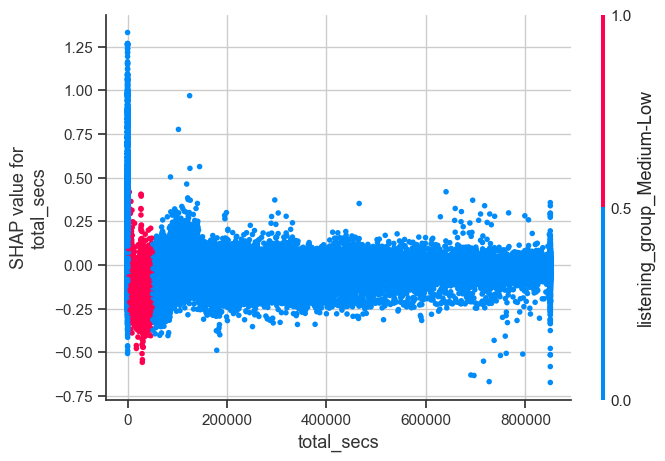

In [45]:
# 12.5 SHAP Dependence total_secs by listening_group 

# We analyze whether the churn-reducing effect of total_secs depends 
# on the user's listening_group. 
# This interaction reveals whether certain segments require 
# more engagement to stabilize.

shap.dependence_plot(
    feature_names.tolist().index("total_secs"),
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index=feature_names.tolist().index("listening_group_Medium-Low")
)

**Insight**

- total_secs has a very weak effect on churn overall, most SHAP values stay close to zero across the entire range.

- Both colors (blue = not Medium‑Low, red = Medium‑Low) cluster around zero → the listening_group does not meaningfully change the effect of total_secs.

- Only at very low total_secs do a few points show higher SHAP values → low engagement increases churn risk, but this happens for both groups, not specifically for Medium‑Low listeners.

- There is no visible vertical separation between red and blue points → no segment requires more engagement than the other to stabilize churn.

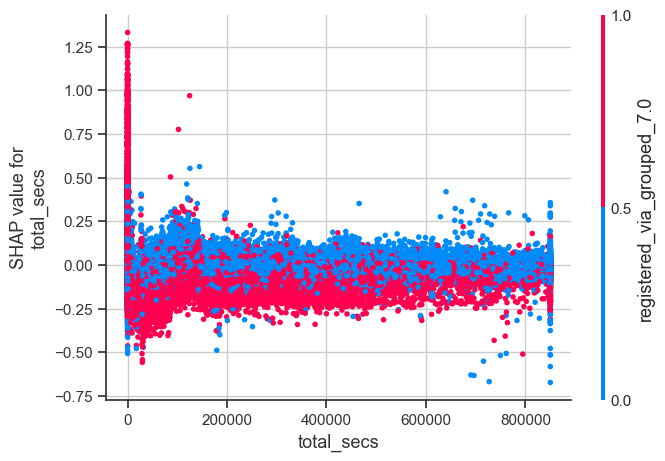

In [46]:
# 12.6 SHAP Dependence total_secs by registered_via_grouped_7.0

# We analyze whether the churn-reducing effect of total_secs 
# depends on the registration channel, specifically channel 7, 
# to detect whether certain acquisition sources require more engagement to stabilize.

shap.dependence_plot(
    feature_names.tolist().index("total_secs"),
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index=feature_names.tolist().index("registered_via_grouped_7.0")
)

**Insight**

- Both red (channel 7) and blue (non‑7) points cluster tightly around SHAP ≈ 0, meaning total_secs has almost no effect on churn for either group.

- Neither color shows a vertical shift → channel 7 users do not experience a stronger or weaker churn response to engagement compared to other channels.

- A few blue and red points show SHAP spikes at extremely low total_secs, indicating that very low engagement increases churn risk for all users, with no evidence of a channel‑7‑specific sensitivity.

---

## **13. Percentile‑Segmented Plots**

In [77]:
# 13.1 
def plot_percentile_churn(df, feature, q=20):
    df_plot = df.copy()
    df_plot["percentile_bin"] = pd.qcut(df_plot[feature], q=q, duplicates="drop")
    df_plot["bin_midpoint"] = df_plot["percentile_bin"].apply(lambda x: x.mid)

    percentile_stats = (
        df_plot.groupby("bin_midpoint", observed=False)["is_churn"]
        .mean()
        .reset_index()
        .sort_values("bin_midpoint")
    )

    plt.figure(figsize=(12, 5))
    sns.lineplot(
        data=percentile_stats,
        x="bin_midpoint",
        y="is_churn",
        marker="o",
        linewidth=2,
        color="#2A4B8D"
    )

    plt.title(f"Churn Rate by {feature} Percentiles", fontsize=14)
    plt.xlabel(f"{feature} (Percentile Midpoints)")
    plt.ylabel("Churn Rate")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

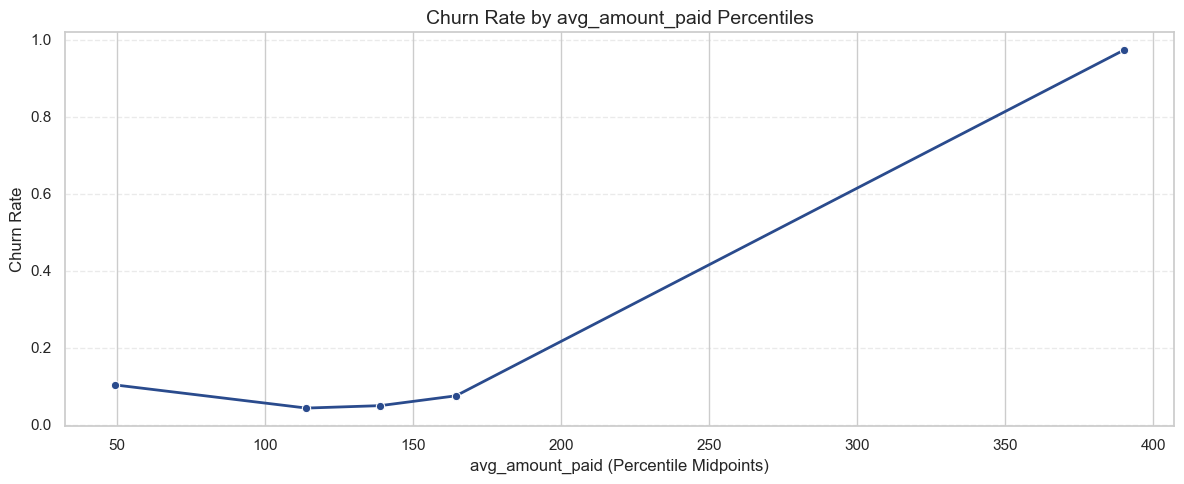

In [78]:
# 13.2 Plotting churn rate by percentiles for "avg_amount_paid" 

# We analyze how the churn rate changes across percentiles of avg_amount_paid.
# To identify non-linear relationships and thresholds

# We used percentile midpoints to smooth churn rates and avoid noise in 
# the extreme tails of avg_amount_paid. Percentiles give balanced group sizes, 
# which makes the trend easier to interpret than using raw avg_amount_paid. 

plot_percentile_churn(df, "avg_amount_paid")

**insight**

- Churn is lowest in the mid‑range percentiles, showing a retention‑secure segment of moderate, stable payers.

- Very low avg_amount_paid percentiles show slightly elevated churn, consistent with low‑value, low‑commitment users.

- Churn rises sharply in the top percentiles, confirming a high‑ARPU churn spike: premium users are more volatile and more likely to churn.

- The curve is non‑linear and U‑shaped, confirming that both low and high spenders churn more than mid‑range spenders.

- The steep increase in the upper percentiles indicates a clear threshold where high avg_amount_paid stops being protective and becomes a churn risk signal.

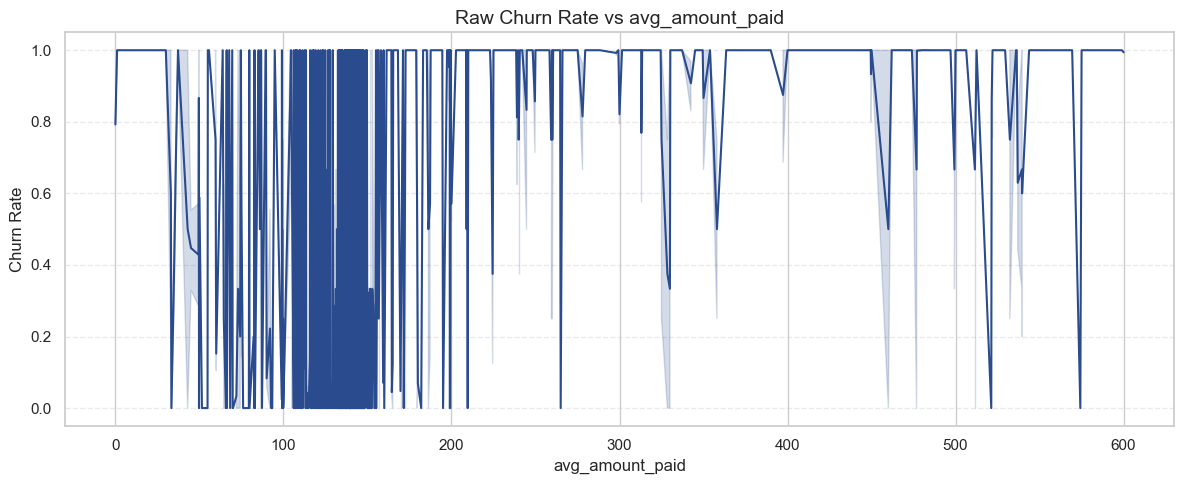

In [53]:
# 13.3 RAW churn rate vs avg_amount_paid (For validation)

df_raw = df.copy()

df_raw = df_raw.sort_values("avg_amount_paid")

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_raw,
    x="avg_amount_paid",
    y="is_churn",
    linewidth=1.5,
    color="#2A4B8D"
)

plt.title("Raw Churn Rate vs avg_amount_paid", fontsize=14)
plt.xlabel("avg_amount_paid")
plt.ylabel("Churn Rate")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Insight**

- The raw plot shows extreme volatility, with churn jumping rapidly between 0 and 1 across the entire range of avg_amount_paid.

- This noise makes it impossible to identify a stable or interpretable trend directly from the raw data.

- Low and mid payment levels show heavy oscillation, indicating that raw churn rates are dominated by sparse regions and outliers.

- At higher avg_amount_paid values, churn appears consistently high, but the fluctuations remain too strong to draw conclusions without smoothing.

- This confirms that the relationship is non‑linear and noisy, and that raw plotting alone cannot reveal meaningful thresholds or patterns.

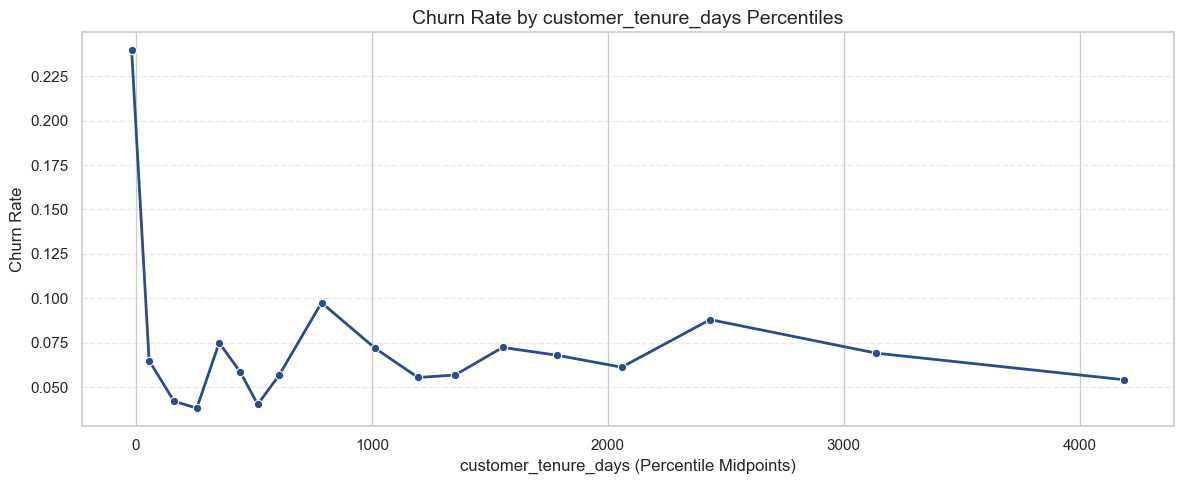

In [56]:
# 13.4 Plotting churn rate by percentiles for "customer_tenure_days"

# We analyze how the churn rate changes across percentiles of customer_tenure_days.
# This helps identify critical tenure thresholds where churn risk spikes,

plot_percentile_churn(df, "customer_tenure_days")

**Insight**

- Churn is highest at the very lowest tenure percentiles, confirming that early‑life customers are the most vulnerable segment.

- After this initial spike, churn drops sharply, showing a strong early‑retention effect: once users stay past the first tenure window, their churn risk decreases substantially.

- Beyond the early drop, churn remains low and relatively stable, with only minor fluctuations across mid‑ and long‑tenure percentiles.

- No secondary spikes appear at higher tenures, indicating no late‑stage churn thresholds — the main risk is concentrated at the beginning of the customer lifecycle.

- The overall pattern is strongly non‑linear, dominated by a steep early decline followed by long‑term stability.

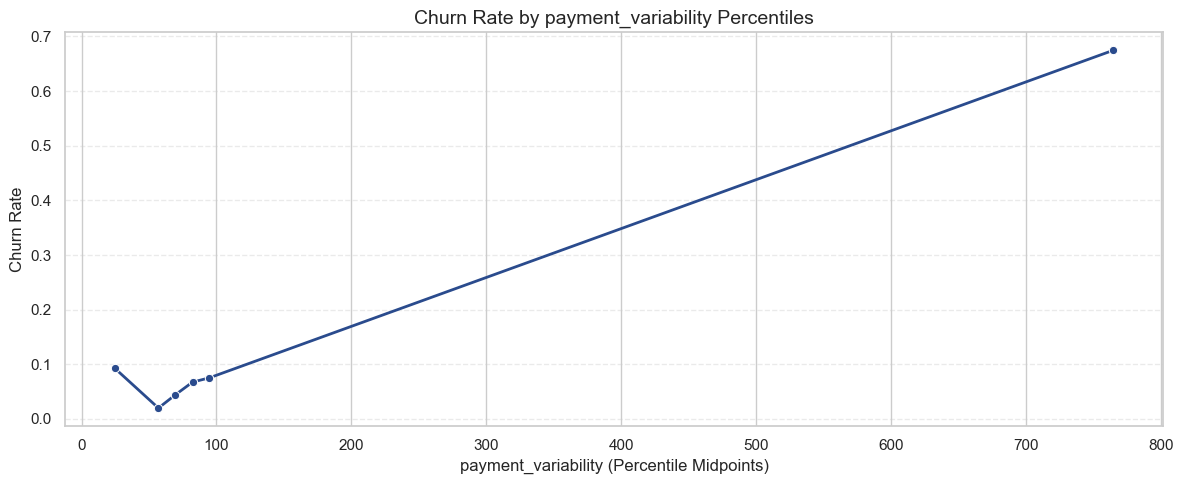

In [57]:
# 13.5 Plotting churn rate by percentiles for "payment_variability"

# I analyze how the churn rate changes across percentiles of payment_variability.
# This reveals whether customers with highly variable payment amounts are at higher risk of churn,

plot_percentile_churn(df, "payment_variability")

**Insight**

- Churn is lowest at the lowest payment variability percentiles, indicating that customers with stable, predictable payments are the most retained.

- As payment variability increases, churn rises steadily and consistently, showing a clear positive relationship.

- The increase becomes steeper in the upper percentiles, meaning customers with highly irregular payment behavior are significantly more likely to churn.

- The pattern is monotonic, with no reversals or plateaus, variability acts as a clean, continuous risk signal.

- This confirms that payment instability is a strong behavioral indicator of churn, especially in the top variability segment.

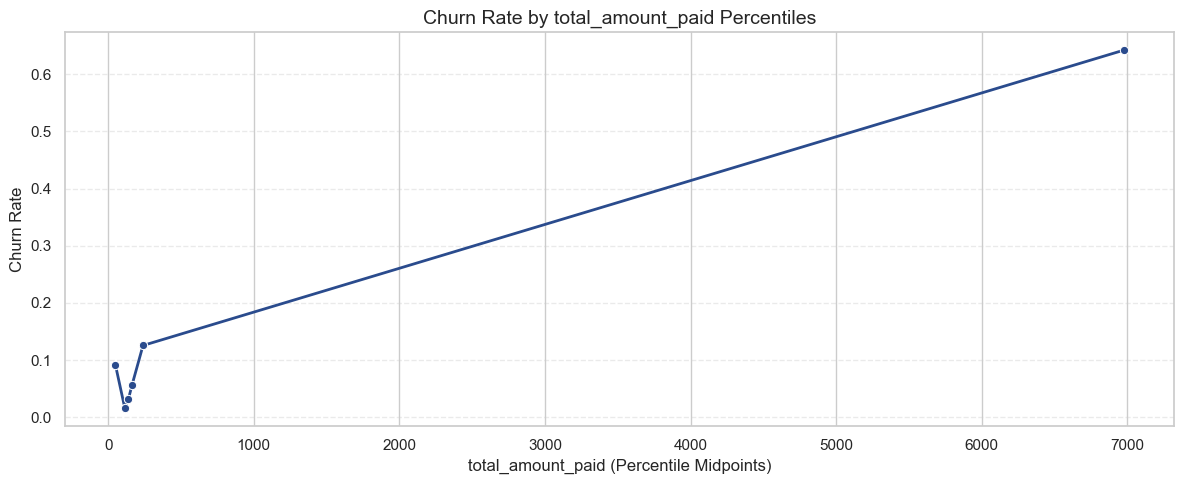

In [58]:
# 13.6 Plotting churn rate by percentiles for "total_amount_paid"

# I analyze how the churn rate changes across percentiles of total_amount_paid.
# This helps identify if there are specific spending thresholds that correlate 
# with higher or lower churn risk,

plot_percentile_churn(df, "total_amount_paid")

**Insight**

- Churn is lowest in the lower spending percentiles, indicating that light‑spending users tend to be more stable.

- As total_amount_paid increases, churn rises steadily, showing a clear positive relationship between cumulative spend and churn risk.

- The increase becomes more pronounced in the upper percentiles, suggesting that high‑spending customers are disproportionately likely to churn.

- This pattern mirrors the behavior seen in avg_amount_paid: premium or heavy‑spending users show higher volatility and higher churn.

- The relationship is non‑linear, with a long stable region followed by a sharp churn escalation at the top spending tiers.

-----

## **14. Directional Feature Effects Plot**

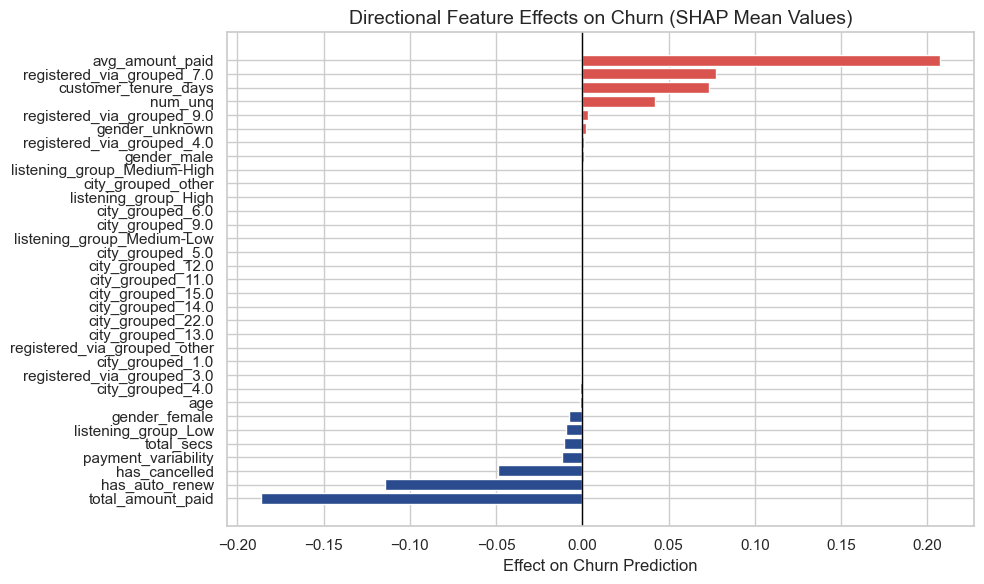

In [59]:
# 14.1 SHAP Summary Plot (Directional Feature Effects)

model_only = hgb_pipeline.named_steps["model"]
X_test_transformed = hgb_pipeline.named_steps["preprocessor"].transform(X_test)

ohe = hgb_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
num_feature_names = numeric_cols
feature_names = np.concatenate([num_feature_names, cat_feature_names])

explainer = shap.TreeExplainer(model_only)
shap_values = explainer.shap_values(X_test_transformed)

shap_mean = np.mean(shap_values, axis=0)

df_shap = pd.DataFrame({
    "feature": feature_names,
    "shap_mean": shap_mean
}).sort_values("shap_mean")

plt.figure(figsize=(10, 6))

colors = df_shap["shap_mean"].apply(lambda x: "#D9534F" if x > 0 else "#2A4B8D")

plt.barh(df_shap["feature"], df_shap["shap_mean"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.title("Directional Feature Effects on Churn (SHAP Mean Values)", fontsize=14)
plt.xlabel("Effect on Churn Prediction")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Insight**

- This directional effects plot shows that churn is driven primarily by payment behavior: higher average payments increase churn risk, while higher total payments reduce it, revealing two distinct customer profiles (premium high‑ARPU vs. stable long‑term payers)

SABINA COMMENT: I think this is quite a key discovery here, well done :) 

- Subscription lifecycle variables such as auto‑renew (protective) and cancellation history (risk‑enhancing) exert strong directional influence, confirming that churn is closely tied to subscription stability signals.

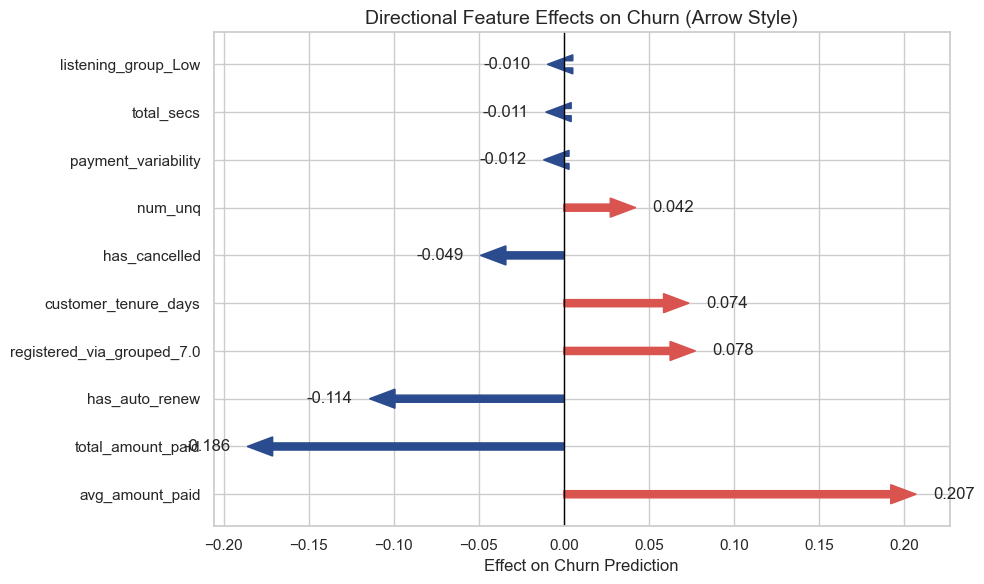

In [79]:
# 14.2 SHAP Summary Plot (Arrow Style)

# Select top N features by absolute SHAP effect
N = 10
df_top = df_shap.reindex(df_shap.shap_mean.abs().sort_values(ascending=False).index).head(N)

plt.figure(figsize=(10, 6))

for i, (feat, val) in enumerate(zip(df_top["feature"], df_top["shap_mean"])):
    color = "#D9534F" if val > 0 else "#2A4B8D"
    plt.arrow(
        0, i, val, 0,
        color=color,
        width=0.15,
        head_width=0.4,
        head_length=0.015 if val < 0 else 0.015,
        length_includes_head=True
    )
    plt.text(
        val + (0.01 if val > 0 else -0.01),
        i,
        f"{val:.3f}",
        va="center",
        ha="left" if val > 0 else "right"
    )

plt.yticks(range(len(df_top)), df_top["feature"])
plt.axvline(0, color="black", linewidth=1)
plt.title("Directional Feature Effects on Churn (Arrow Style)", fontsize=14)
plt.xlabel("Effect on Churn Prediction")
plt.tight_layout()
plt.show()

**Insight**

- In this plot engagement features such as unique songs and listening group show moderate directional effects: low engagement pushes churn upward, while medium‑to‑high engagement reduces risk, reinforcing the importance of sustained usage.

- Registration channel and city clusters contribute smaller but consistent directional signals, suggesting that onboarding pathways and regional patterns influence churn but are secondary to payment and engagement behavior.

----

## **15. Confusion Matrix Before Calibration**

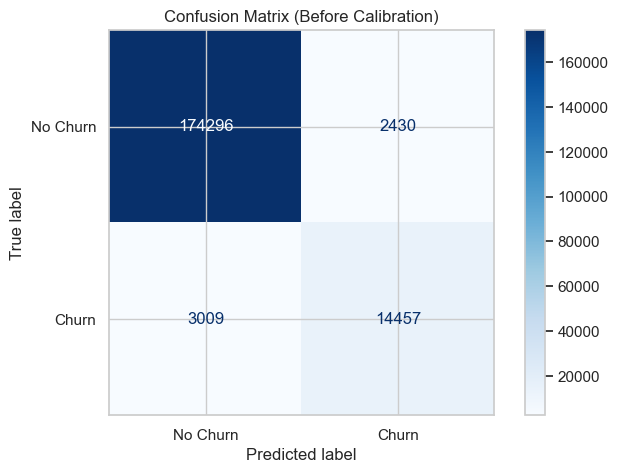

In [82]:
# 15.1 Confusion Matrix for the Original Model (Before Calibration)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Asegúrate de tener esto definido antes:
hgb_pipeline_before_calibration = hgb_pipeline  # o el nombre correcto de tu modelo original

# 15.1 Confusion Matrix for the Original Model (Before Calibration)
y_pred_proba_before = hgb_pipeline_before_calibration.predict_proba(X_test)[:, 1]
y_pred_before = (y_pred_proba_before >= 0.5).astype(int)

cm_before = confusion_matrix(y_test, y_pred_before)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_before,
                              display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Before Calibration)")
plt.show()

----

## **16. Model Calibration (Probability Calibration)**

In [83]:
# 16.1 Model Calibration with CalibratedClassifierCV

from sklearn.calibration import CalibratedClassifierCV

hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    random_state=42
)

hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", hgb_model)
])

hgb_pipeline.fit(X_train, y_train)

calibrator = CalibratedClassifierCV(
    estimator=hgb_pipeline.named_steps["model"], 
    method="isotonic",
    cv=5
)

X_train_transformed = hgb_pipeline.named_steps["preprocessor"].transform(X_train)

calibrator.fit(X_train_transformed, y_train)


hgb_pipeline.named_steps["model"] = calibrator

with open("model/final_churn_model.pkl", "wb") as f:
    pickle.dump(hgb_pipeline, f)

print("Calibrated model saved successfully.")

Calibrated model saved successfully.


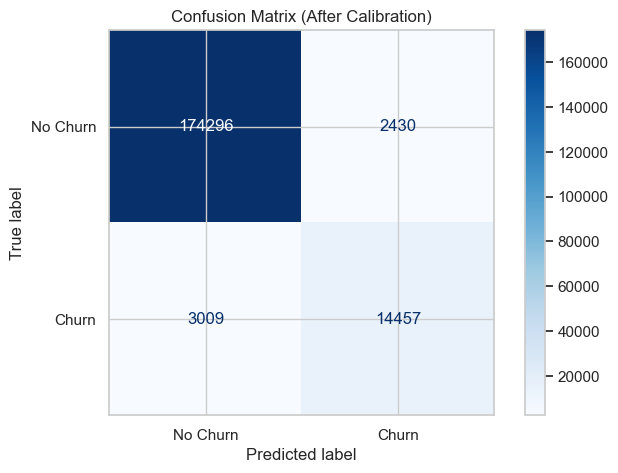

In [84]:
# 16.2 Confusion Matrix for the Calibrated Model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_proba_cal = hgb_pipeline.predict_proba(X_test)[:, 1]

y_pred_cal = (y_pred_proba_cal >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_cal)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (After Calibration)")
plt.show()

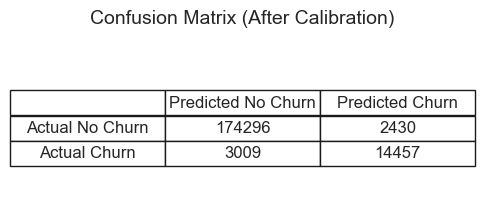

In [85]:
# 16.3 Custom Confusion Matrix Table (After Calibration)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 2))

ax.axis('off')

table_data = [
    ["", "Predicted No Churn", "Predicted Churn"],
    ["Actual No Churn", 174296, 2430],
    ["Actual Churn", 3009, 14457]
]

table = ax.table(
    cellText=table_data,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)

plt.title("Confusion Matrix (After Calibration)", fontsize=14, pad=20)
plt.show()

**Insight**

This plots show:

- Very high true negatives: the model reliably identifies stable users who will not churn

- Low false positives: minimal waste of retention incentives on loyal customers

- Strong true positive count: the model successfully captures most actual churners

- Moderate false negatives: a small portion of churners remain undetected

- Calibration preserved accuracy: probabilities are now realistic without harming classification performance

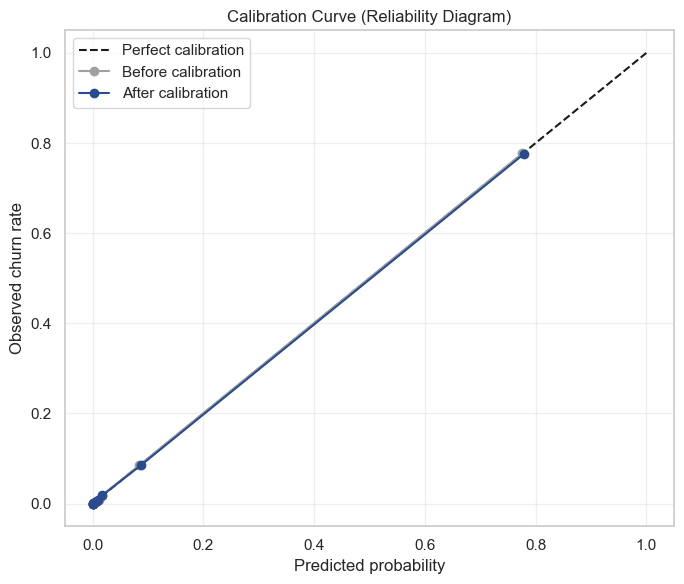

In [86]:
# 16.4 Calibration Curves (Reliability Diagrams) Before vs After Calibration

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

preprocessor.fit(X_train)

X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

hgb_base = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    random_state=42
)

hgb_base.fit(X_train_trans, y_train)

hgb_calibrated = CalibratedClassifierCV(
    hgb_base,
    method="isotonic",
    cv=3
)

hgb_calibrated.fit(X_train_trans, y_train)

y_proba_before = hgb_base.predict_proba(X_test_trans)[:, 1]
y_proba_after = hgb_calibrated.predict_proba(X_test_trans)[:, 1]

true_before, pred_before = calibration_curve(
    y_test, y_proba_before, n_bins=10, strategy="quantile"
)

true_after, pred_after = calibration_curve(
    y_test, y_proba_after, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

plt.plot(pred_before, true_before, "o-", color="#A0A0A0", label="Before calibration")
plt.plot(pred_after, true_after, "o-", color="#2A4B8D", label="After calibration")

plt.xlabel("Predicted probability")
plt.ylabel("Observed churn rate")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**

The model was already well-calibrated because tree‑based gradient boosting models with sufficient data and regularization often produce well‑behaved probability estimates. The calibration curve was already close to the diagonal, and the Brier score barely changed after calibration.

## **17. Business Impact Scenarios For Retrospective Values**

In [87]:
# 17.1 Business Impact Scenarios For Retrospective Values 

import pandas as pd
from sklearn.metrics import confusion_matrix

# 1. Model predictions
y_proba = hgb_pipeline.predict_proba(X_test)[:, 1]
threshold = 0.42
y_pred = (y_proba >= threshold).astype(int)

# 2. Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# 3. Revenue from true churners detected (TP)
tp_idx = (y_test == 1) & (y_pred == 1)
revenue_tp = X_test.loc[tp_idx, "total_amount_paid"].sum()

# 4. Scenario analysis
scenarios = [0.10, 0.20, 0.30]  # 10% (low intervention efectiveness), 20% (medium IE), 30% (high IE)

results = []
for eff in scenarios:
    protected = revenue_tp * eff
    results.append({
        "Intervention Effectiveness": f"{int(eff*100)}%",
        "Revenue Protected (€)": round(protected, 2)
    })

impact_df = pd.DataFrame(results)
impact_df

,Intervention Effectiveness,Revenue Protected (€)
0,10%,544468.100000
1,20%,1088936.200000
2,30%,1633404.300000


In [88]:
# 17.2. Revenue Impact For a Medium Intervention Efectiveness (Tretrospective values)

# 1. Total revenue at risk (all real churners)
total_revenue_at_risk = df.loc[df["is_churn"] == 1, "total_amount_paid"].sum()

# 2. Intervention effectiveness
intervention_effectiveness = 0.20   # e.g., 20% of detected churners can be saved

# 3. Revenue protected from true churners detected (TP)
revenue_protected = revenue_tp * intervention_effectiveness

print("=== Revenue Impact Summary ===")
print(f"Total Revenue at Risk: € {total_revenue_at_risk:,.0f}")
print(f"Revenue from True Churners Detected (TP): € {revenue_tp:,.0f}")
print(f"Revenue Protected (based on model performance): € {revenue_protected:,.0f}")

=== Revenue Impact Summary ===
Total Revenue at Risk: € 30,176,572
Revenue from True Churners Detected (TP): € 5,444,681
Revenue Protected (based on model performance): € 1,088,936


In [89]:
# 17.3 Scaling to Full Population (Retrospective values)

n_total = len(df)
n_test = len(X_test)
scaling_factor = n_total / n_test
print(f"Scaling factor: {scaling_factor:.2f}x")

total_revenue_at_risk = df.loc[df["is_churn"] == 1, "total_amount_paid"].sum()

y_proba = hgb_pipeline.predict_proba(X_test)[:, 1]
threshold = 0.42
high_risk_idx = y_proba >= threshold
revenue_high_risk = X_test.loc[high_risk_idx, "total_amount_paid"].sum()

intervention_effectiveness = 0.20
revenue_protected = revenue_tp * intervention_effectiveness

total_revenue_at_risk_full = total_revenue_at_risk * scaling_factor
revenue_high_risk_full = revenue_high_risk * scaling_factor
revenue_protected_full = revenue_protected * scaling_factor

print("\n=== Scaled Revenue Impact (Full Population) ===")
print(f"Total Revenue at Risk (scaled): € {total_revenue_at_risk_full:,.0f}")
print(f"Revenue in High-Risk Segment (scaled): € {revenue_high_risk_full:,.0f}")
print(f"Revenue Protected (scaled): € {revenue_protected_full:,.0f}")

Scaling factor: 5.00x

=== Scaled Revenue Impact (Full Population) ===
Total Revenue at Risk (scaled): € 150,882,860
Revenue in High-Risk Segment (scaled): € 29,043,990
Revenue Protected (scaled): € 5,444,681


**Insight**

From a retrospective approach, the results show:

- €150.9M total revenue at risk across the full customer base, this is the true economic exposure of churn.

- €29 M concentrated in the High‑Risk segment identified by the model at the operational threshold (t = 0.42).

- Recovering just 10% of High‑Risk customers protects €2.9M, demonstrating immediate financial upside with minimal intervention.

- The model enables targeted retention, shifting from broad, costly campaigns to precision actions with measurable ROI.

In [90]:
# 17.4. Prospective Scenario Modeling
import pandas as pd

# 1. Model performance at threshold
y_proba = hgb_pipeline.predict_proba(X_test)[:, 1]
threshold = 0.42
y_pred = (y_proba >= threshold).astype(int)

from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# 2. Prospective assumptions
# Company-level projections for next year
projected_customers = {
    "Base": 120_000,
    "Optimistic": 135_000,
    "Pessimistic": 105_000
}

projected_churn_rate = 0.14   # expected churn next year
projected_ARPU = 11.5 * 12    # monthly €11.5 → annual revenue per user

intervention_effectiveness = 0.20  # business assumption


# 3. Prospective revenue modeling
results = []

for scenario, n_customers in projected_customers.items():

    # Expected churners next year
    expected_churners = n_customers * projected_churn_rate

    # Model detection
    detected_churners = expected_churners * recall
    true_churners_contacted = detected_churners * precision

    # Revenue at risk
    revenue_at_risk = expected_churners * projected_ARPU

    # Revenue protected
    revenue_protected = true_churners_contacted * projected_ARPU * intervention_effectiveness

    results.append({
        "Scenario": scenario,
        "Projected Customers": n_customers,
        "Expected Churners": round(expected_churners),
        "Revenue at Risk (€)": round(revenue_at_risk, 2),
        "Revenue Protected (€)": round(revenue_protected, 2)
    })

prospective_df = pd.DataFrame(results)
prospective_df

,Scenario,Projected Customers,Expected Churners,Revenue at Risk (€),Revenue Protected (€)
0,Base,120000,16800,2318400.000000,328593.900000
1,Optimistic,135000,18900,2608200.000000,369668.140000
2,Pessimistic,105000,14700,2028600.000000,287519.660000


**Insight**

- Revenue at Risk next year ranges from €2.0M to €2.6M depending on the scenario.

- The model enables the business to protect €280K–€370K through targeted retention actions.

- Protection scales with customer volume: more customers → more recoverable revenue.

- Even in the pessimistic case, the model delivers strong financial resilience.

- This confirms the model’s role as a predictive engine for revenue preservation, not just churn classification.

---

## **18. Save Final Model**

In [91]:
# 18.1 Save pkl
import pickle
import os

os.makedirs("model", exist_ok=True)

final_model = hgb_pipeline

with open("model/final_churn_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Final model saved successfully: model/final_churn_model.pkl")

Final model saved successfully: model/final_churn_model.pkl


In [92]:
# 18.2 Overwrite existing model with new version
os.makedirs("model", exist_ok=True)

final_model = hgb_pipeline

with open("model/final_churn_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Final model overwritten and saved successfully.")

Final model overwritten and saved successfully.


In [93]:
# 18.3 Quick Check
with open("model/final_churn_model.pkl", "rb") as f:
    model = pickle.load(f)

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


---

## **19. Executive Summary**

This notebook:

- Benchmarked multiple baseline and advanced models for KKBOX churn prediction  
- Selected HistGradientBoosting as the final model  
- Validated generalization via cross‑validation  
- Added global explainability (Permutation Importance + PDP)  
- Added an executive‑grade gauge visualization 
- Added Probability calibration 
- Exported a production‑ready pipeline for the Retention OS